# Importing

In [ ]:
import json
import torch
import pandas as pd
from sklearn.model_selection import train_test_split
from transformers import AutoTokenizer, AutoModelForSequenceClassification, RobertaTokenizer, RobertaForSequenceClassification, Trainer, TrainingArguments
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# Для визуализации с Plotly
import plotly.graph_objs as go
import plotly.express as px
import plotly.figure_factory as ff

# Для работы с данными и тензорами
from torch.utils.data import Dataset, DataLoader
import collections

from transformers import pipeline

In [ ]:
!huggingface-cli login


    _|    _|  _|    _|    _|_|_|    _|_|_|  _|_|_|  _|      _|    _|_|_|      _|_|_|_|    _|_|      _|_|_|  _|_|_|_|
    _|    _|  _|    _|  _|        _|          _|    _|_|    _|  _|            _|        _|    _|  _|        _|
    _|_|_|_|  _|    _|  _|  _|_|  _|  _|_|    _|    _|  _|  _|  _|  _|_|      _|_|_|    _|_|_|_|  _|        _|_|_|
    _|    _|  _|    _|  _|    _|  _|    _|    _|    _|    _|_|  _|    _|      _|        _|    _|  _|        _|
    _|    _|    _|_|      _|_|_|    _|_|_|  _|_|_|  _|      _|    _|_|_|      _|        _|    _|    _|_|_|  _|_|_|_|

    A token is already saved on your machine. Run `huggingface-cli whoami` to get more information or `huggingface-cli logout` if you want to log out.
    Setting a new token will erase the existing one.
    To log in, `huggingface_hub` requires a token generated from https://huggingface.co/settings/tokens .
Enter your token (input will not be visible): 
Add token as git credential? (Y/n) n
Token is valid (permission: read)

In [ ]:
# Определение устройства
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


# Data Loading

## Загрузка данных

In [ ]:
file_paths = {
    "train": "/content/dailydialog_train.json",
    "valid": "/content/dailydialog_valid.json",
    "test": "/content/dailydialog_test.json"
}

data = {}
for key, path in file_paths.items():
    with open(path, "r", encoding="utf-8") as f:
        data[key] = json.load(f)


In [ ]:
# Преобразование JSON в DataFrame
def json_to_dataframe(json_data):
    records = []
    for conv_id, convs in json_data.items():
        for conv in convs:
            for message in conv:
                records.append({
                    "conversation_id": conv_id,
                    "turn": message["turn"],
                    "speaker": message["speaker"],
                    "utterance": message["utterance"],
                    "emotion": message["emotion"]
                })
    return pd.DataFrame(records)

train_df = json_to_dataframe(data["train"])
valid_df = json_to_dataframe(data["valid"])
test_df = json_to_dataframe(data["test"])

## Исследование уникальных эмоций

In [ ]:
# Анализ данных
print("Train dataset shape:", train_df.shape)
print("Validation dataset shape:", valid_df.shape)
print("Test dataset shape:", test_df.shape)
print("Emotion distribution in train dataset:")
print(train_df["emotion"].value_counts())

Train dataset shape: (8206, 5)
Validation dataset shape: (493, 5)
Test dataset shape: (2405, 5)
Emotion distribution in train dataset:
emotion
neutral      3644
happiness    3550
surprise      365
anger         275
sadness       209
disgust       106
fear           45
happy           5
sad             3
excited         2
surprised       1
angry           1
Name: count, dtype: int64


## Преобразование эмоций в метки

In [ ]:
emotion_mapping = {
    'neutral': 'neutral',
    'happiness': 'happiness',  # Исправлено
    'happines': 'happiness',
    'happy': 'happiness',   # Исправлено, будет соответствовать 'happiness'
    'sad': 'sadness',        # Объединено с 'sadness'
    'sadness': 'sadness',    # Объединено с 'sad'
    'anger': 'anger',
    'angry': 'anger',
    'disgust': 'disgust',
    'surprise': 'surprise',
    'surprised': 'surprise',
    'excited': 'excited',
    'fear': 'excited'
}

# Преобразуем метки эмоций в тренировочном, валидирующем и тестовом наборах
def update_emotions_column(dataset, mapping):
    dataset['emotion'] = dataset['emotion'].apply(lambda x: mapping.get(x, None))
    return dataset

# Обновление меток в датасетах
train_df = update_emotions_column(train_df, emotion_mapping)
valid_df = update_emotions_column(valid_df, emotion_mapping)
test_df = update_emotions_column(test_df, emotion_mapping)

# Проверяем результаты
print("Updated train emotions:", train_df['emotion'].unique())
print("Updated validation emotions:", valid_df['emotion'].unique())
print("Updated test emotions:", test_df['emotion'].unique())

Updated train emotions: ['happiness' 'neutral' 'anger' 'surprise' 'disgust' 'sadness' 'excited']
Updated validation emotions: ['neutral' 'happiness' 'anger' 'disgust' 'surprise' 'sadness' 'excited']
Updated test emotions: ['neutral' 'surprise' 'anger' 'disgust' 'happiness' 'sadness' 'excited']


In [ ]:
# Анализ данных
print("Train dataset shape:", train_df.shape)
print("Validation dataset shape:", valid_df.shape)
print("Test dataset shape:", test_df.shape)
print("Emotion distribution in train dataset:")
print(train_df["emotion"].value_counts())

Train dataset shape: (8206, 5)
Validation dataset shape: (493, 5)
Test dataset shape: (2405, 5)
Emotion distribution in train dataset:
emotion
neutral      3644
happiness    3555
surprise      366
anger         276
sadness       212
disgust       106
excited        47
Name: count, dtype: int64


In [ ]:
train_df.head()

,conversation_id,turn,speaker,utterance,emotion
0,tr_4466,1,A,"Hey , you wanna see a movie tomorrow ?",happiness
1,tr_4466,2,B,Sounds like a good plan . What do you want to ...,happiness
2,tr_4466,3,A,How about Legally Blonde .,neutral
3,tr_4466,4,B,"Ah , my girlfriend wanted to see that movie . ...",neutral
4,tr_4466,5,A,Isn't that a scary movie ?,neutral


## Визуализация распределения эмоций

In [ ]:
label_counts = collections.Counter(train_df.emotion)

sorted_labels = sorted(label_counts.keys(), key=lambda label: label_counts[label], reverse=True)
emotion_names = emotion_mapping.keys()
balance_counts = [label_counts[label] for label in sorted_labels]

colors = [
    'rgba(31, 119, 180, 0.8)',  # neutral - синий
    'rgba(255, 127, 14, 0.8)',  # happiness - оранжевый
    'rgba(44, 160, 44, 0.8)',   # sadness - зеленый
    'rgba(214, 39, 40, 0.8)',   # anger - красный
    'rgba(148, 103, 189, 0.8)', # disgust - фиолетовый
    'rgba(140, 86, 75, 0.8)',   # surprise - коричневый
    'rgba(227, 119, 194, 0.8)', # excited - розовый
    'rgba(127, 127, 127, 0.8)'  # fear - серый
]

fig = go.Figure()

for emotion, count, color in zip(emotion_names, balance_counts, colors):
    fig.add_trace(go.Bar(
        x=[emotion],
        y=[count],
        name=emotion,
        text=[count],
        textposition='auto',
        marker_color=color
    ))

fig.update_layout(
    title='<span style="font-size:32px; font-family:Times New Roman">Распределение эмоций в наборе данных</span>',
    xaxis_title='Эмоции',
    yaxis_title='Количество примеров',
    barmode='group',
    template='plotly_white'
)

fig.show()


## Устранение дисбаланса классов

In [ ]:
# 3. Загрузка генеративной модели (GPT-2)
generator = pipeline("text-generation", model="gpt2")

config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

Device set to use cuda:0


In [ ]:
# Подготовка данных для fine-tuning
def prepare_data_for_finetuning(df, text_column="utterance", emotion_column="emotion"):
    return df.apply(lambda x: f"emotion: {x[emotion_column]} <|endoftext|> {x[text_column]} <|endoftext|>", axis=1).tolist()

# Создаём обучающую выборку
finetuning_texts = prepare_data_for_finetuning(train_df)

# Сохраняем подготовленный текст в файл
with open("finetuning_data.txt", "w", encoding="utf-8") as f:
    for line in finetuning_texts:
        f.write(line + "\n")

In [ ]:
from transformers import GPT2LMHeadModel, GPT2Tokenizer

# Загрузка модели и токенизатора GPT-2
model = GPT2LMHeadModel.from_pretrained("gpt2")
tokenizer = GPT2Tokenizer.from_pretrained("gpt2")

# Добавляем специальные токены (например, <|endoftext|>)
tokenizer.pad_token = tokenizer.eos_token

In [ ]:
from torch.utils.data import Dataset

class TextDataset(Dataset):
    def __init__(self, tokenizer, file_path, block_size=128):
        self.examples = []

        with open(file_path, encoding="utf-8") as f:
            lines = f.read().splitlines()

        # Токенизация данных
        for line in lines:
            tokenized = tokenizer(line, truncation=True, padding="max_length", max_length=block_size, return_tensors="pt")
            self.examples.append({
                "input_ids": tokenized["input_ids"].squeeze(0),  # Преобразование в тензор
                "attention_mask": tokenized["attention_mask"].squeeze(0),
                "labels": tokenized["input_ids"].squeeze(0)  # Метки такие же, как и input_ids
            })

    def __len__(self):
        return len(self.examples)

    def __getitem__(self, i):
        return self.examples[i]


# Подготовка данных
train_dataset = TextDataset(tokenizer, "finetuning_data.txt", block_size=128)

In [ ]:
# Пример одного элемента из датасета
print(train_dataset[0])  # Должно вывести {"input_ids": ..., "attention_mask": ..., "labels":...}


{'input_ids': tensor([  368,  9650,    25, 12157,   220, 50256, 14690,   837,   345, 18869,
          766,   257,  3807,  9439,  5633,   220, 50256, 50256, 50256, 50256,
        50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256,
        50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256,
        50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256,
        50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256,
        50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256,
        50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256,
        50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256,
        50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256,
        50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256,
        50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256,
        50256, 50256, 50256, 50256, 50256, 50256, 

In [ ]:
from transformers import DataCollatorForLanguageModeling

# Создаем DataCollator для языкового моделирования
data_collator = DataCollatorForLanguageModeling(
    tokenizer=tokenizer,
    mlm=False
)

In [ ]:
from transformers import Trainer, TrainingArguments

# Параметры обучения
training_args = TrainingArguments(
    output_dir="./results",  # Папка для сохранения результатов
    overwrite_output_dir=True,
    num_train_epochs=3,  # Количество эпох
    per_device_train_batch_size=4,  # Размер батча
    save_steps=10_000,
    save_total_limit=2,
    logging_dir="./logs",  # Папка для логов
    logging_steps=500,
)

# Обновленный Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    data_collator=data_collator  # Используем data_collator вместо tokenizer
)


In [ ]:
trainer.train()

Step,Training Loss
500,2.696300
1000,2.504900
1500,2.464100
2000,2.452400
2500,2.155700
3000,2.107400
3500,2.111100
4000,2.116400
4500,1.973900
5000,1.940000


TrainOutput(global_step=6156, training_loss=2.1869537075902827, metrics={'train_runtime': 1029.937, 'train_samples_per_second': 23.902, 'train_steps_per_second': 5.977, 'total_flos': 1608121810944000.0, 'train_loss': 2.1869537075902827, 'epoch': 3.0})

In [ ]:
# Сохранение модели и токенизатора
model.save_pretrained("./finetuned_gpt2")
tokenizer.save_pretrained("./finetuned_gpt2")

('./finetuned_gpt2/tokenizer_config.json',
 './finetuned_gpt2/special_tokens_map.json',
 './finetuned_gpt2/vocab.json',
 './finetuned_gpt2/merges.txt',
 './finetuned_gpt2/added_tokens.json')

In [ ]:
def generate_texts_for_class_in_batches(emotion, total_samples, batch_size=10, max_length=50):
    """
    Генерация текстов партиями для предотвращения переполнения памяти GPU.
    """
    prompt = f"emotion: {emotion} <|endoftext|>"
    generated_texts = []

    for _ in range(total_samples // batch_size):
        batch = generator(prompt, max_length=max_length, num_return_sequences=batch_size)
        generated_texts.extend([text['generated_text'] for text in batch])

    # Для оставшихся текстов, если total_samples не делится на batch_size
    remaining = total_samples % batch_size
    if remaining > 0:
        batch = generator(prompt, max_length=max_length, num_return_sequences=remaining)
        generated_texts.extend([text['generated_text'] for text in batch])

    return generated_texts

# Анализ данных: Проверяем количество примеров для каждого класса
emotion_counts = train_df["emotion"].value_counts()

# Указываем минимальное количество примеров
min_samples = 3000

In [ ]:
# Подготовка для хранения новых данных
synthetic_data = []
for emotion, count in emotion_counts.items():
    if count < min_samples:
        print(f"Генерация данных для класса: {emotion}")
        num_to_generate = min_samples - count
        generated_texts = generate_texts_for_class_in_batches(emotion, total_samples=num_to_generate, batch_size=10)

        # Добавляем сгенерированные данные в общий список
        for text in generated_texts:
            synthetic_data.append({"utterance": text, "emotion": emotion})

Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


Генерация данных для класса: surprise


Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end gene

Генерация данных для класса: anger


Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end gene

...

Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end gene

Генерация данных для класса: disgust


Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end gene

Генерация данных для класса: excited


Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end gene

In [ ]:
# Преобразование сгенерированных данных в DataFrame
synthetic_df = pd.DataFrame(synthetic_data)

synthetic_df['utterance'] = synthetic_df['utterance'].str.replace(r'emotion: \w+ <\|endoftext\|>', '', regex=True).str.strip()

# Объединение с оригинальным тренировочным набором
balanced_train_df = pd.concat([train_df, synthetic_df], ignore_index=True)

In [ ]:
synthetic_df.head()

,utterance,emotion
0,"It doesn't always work, but when it does, it c...",surprise
1,"The NFL and NFLPA could use a new ""game-changi...",surprise
2,The only person who ever managed to convince u...,surprise
3,"Nate Silver's wife Susanne Silver, who suffere...",surprise
4,It took me a while to get used to the sound qu...,surprise


In [ ]:
# Проверка нового распределения классов
print("Распределение классов после устранения дисбаланса:")
print(balanced_train_df['emotion'].value_counts())

Распределение классов после устранения дисбаланса:
emotion
neutral      3644
happiness    3555
anger        3000
surprise     3000
disgust      3000
sadness      3000
excited      3000
Name: count, dtype: int64


In [ ]:
balanced_train_df.to_csv('balanced_train_1000.csv', index=False, encoding='utf-8')
print("Сбалансированный датасет сохранён как 'balanced_train_1000.csv'.")

Сбалансированный датасет сохранён как 'balanced_train_1000.csv'.


In [ ]:
balanced_train_df = pd.read_csv('/content/balanced_train_1000 (1).csv')

In [ ]:
balanced_train_df.head(2)

,conversation_id,turn,speaker,utterance,emotion
0,tr_4466,1.0,A,"Hey , you wanna see a movie tomorrow ?",happiness
1,tr_4466,2.0,B,Sounds like a good plan . What do you want to ...,happiness


In [ ]:
label_counts = collections.Counter(balanced_train_df.emotion)

sorted_labels = sorted(label_counts.keys(), key=lambda label: label_counts[label], reverse=True)
emotion_names = emotion_mapping.keys()
balance_counts = [label_counts[label] for label in sorted_labels]

colors = [
    'rgba(31, 119, 180, 0.8)',  # neutral - синий
    'rgba(255, 127, 14, 0.8)',  # happiness - оранжевый
    'rgba(44, 160, 44, 0.8)',   # sadness - зеленый
    'rgba(214, 39, 40, 0.8)',   # anger - красный
    'rgba(148, 103, 189, 0.8)', # disgust - фиолетовый
    'rgba(140, 86, 75, 0.8)',   # surprise - коричневый
    'rgba(227, 119, 194, 0.8)', # excited - розовый
    'rgba(127, 127, 127, 0.8)'  # fear - серый
]

fig = go.Figure()

for emotion, count, color in zip(emotion_names, balance_counts, colors):
    fig.add_trace(go.Bar(
        x=[emotion],
        y=[count],
        name=emotion,
        text=[count],
        textposition='auto',
        marker_color=color
    ))

fig.update_layout(
    title='<span style="font-size:32px; font-family:Times New Roman">Распределение эмоций в наборе данных</span>',
    xaxis_title='Эмоции',
    yaxis_title='Количество примеров',
    barmode='group',
    template='plotly_white'
)

fig.show()

## Подготовка текстов и меток. Разделение данных на обучающую и валидационную выборки

In [ ]:
train_df = balanced_train_df

In [ ]:
emotion_mapping = {
    'neutral': 0,
    'happiness': 1,
    'sadness': 2,
    'anger': 3,
    'disgust': 4,
    'surprise': 5,
    'excited': 6,
    'fear': 7
}

In [ ]:
# Разделение на обучающую и валидационную выборки
texts = train_df.utterance.tolist()
labels = [emotion_mapping[label] for label in train_df.emotion.tolist()]
X_train, X_val, y_train, y_val = train_test_split(texts, labels, test_size=0.1, random_state=42)

In [ ]:
print(set(type(label) for label in y_train))
print(set(type(label) for label in y_val))

{<class 'int'>}
{<class 'int'>}


In [ ]:
# Убедимся, что данные не содержат пустых строк
X_train = [text for text in X_train if isinstance(text, str) and text.strip()]
X_val = [text for text in X_val if isinstance(text, str) and text.strip()]

# Classic Models

## Векторизация текста с использованием TF-IDF

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Векторизация текстов
vectorizer = TfidfVectorizer(max_features=5000)
X_train_tfidf = vectorizer.fit_transform(X_train)
X_val_tfidf = vectorizer.transform(X_val)

## Обучение и оценка модели SVM

In [ ]:
from sklearn.svm import SVC

# Обучение модели SVM
svm_model = SVC(kernel='linear', probability=True)
svm_model.fit(X_train_tfidf, y_train)

# Предсказания и оценка
svm_preds = svm_model.predict(X_val_tfidf)
svm_accuracy = accuracy_score(y_val, svm_preds)
svm_f1 = f1_score(y_val, svm_preds, average='weighted')

print(f"SVM Accuracy: {svm_accuracy:.4f}")
print(f"SVM F1 Score: {svm_f1:.4f}")

SVM Accuracy: 0.3563
SVM F1 Score: 0.3466


## Обучение и оценка модели Наивного Байеса

In [ ]:
from sklearn.naive_bayes import MultinomialNB

# Обучение модели Наивного Байеса
nb_model = MultinomialNB()
nb_model.fit(X_train_tfidf, y_train)

# Предсказания и оценка
nb_preds = nb_model.predict(X_val_tfidf)
nb_accuracy = accuracy_score(y_val, nb_preds)
nb_f1 = f1_score(y_val, nb_preds, average='weighted')

print(f"Naive Bayes Accuracy: {nb_accuracy:.4f}")
print(f"Naive Bayes F1 Score: {nb_f1:.4f}")

Naive Bayes Accuracy: 0.3396
Naive Bayes F1 Score: 0.3178


## Сравнение классических моделей

In [ ]:
data = {
    'Model': ['SVM', 'Naive Bayes'],
    'Accuracy': [0.3563, 0.3396],
    'F1 Score': [0.3466, 0.3178]
}

df = pd.DataFrame(data)
df_sorted = df.sort_values(by='Accuracy', ascending=False)
df_sorted_reset = df_sorted.reset_index(drop=True)
pd.set_option('display.float_format', '{:.4f}'.format)
styled_df = df_sorted_reset.style.set_caption("Сравнение моделей") \
    .background_gradient(cmap='viridis', subset=['Accuracy', 'F1 Score']) \
    .format({
        'Accuracy': "{:.4f}",
        'F1 Score': "{:.4f}"
    }) \
    .set_table_styles(
        [{
            'selector': 'th',
            'props': [('background-color', '#f7f7f9'),
                      ('color', 'black'),
                      ('border', '1px solid black')]
        },
        {
            'selector': 'td',
            'props': [('border', '1px solid black')]
        }]
    )

styled_df

,Model,Accuracy,F1 Score
0,SVM,0.3563,0.3466
1,Naive Bayes,0.3396,0.3178


# NN Models

## Подготовка данных для PyTorch

In [ ]:
# Токенизация
tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")
train_encodings = tokenizer(X_train, truncation=True, padding=True, max_length=128)
val_encodings = tokenizer(X_val, truncation=True, padding=True, max_length=128)

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

In [ ]:
# Подготовка данных для PyTorch
class TextDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx])
        return item

In [ ]:
# Создание PyTorch DataLoader
train_dataset = TextDataset(train_encodings, y_train)
val_dataset = TextDataset(val_encodings, y_val)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=16)

In [ ]:
# Токенизация тестовых данных
test_texts = test_df.utterance.tolist()  # Тексты для тестирования
test_labels = [emotion_mapping[label] for label in test_df.emotion.tolist()]  # Реальные метки

test_encodings = tokenizer(test_texts, truncation=True, padding=True, max_length=128)
test_dataset = TextDataset(test_encodings, test_labels)
test_loader = DataLoader(test_dataset, batch_size=32)

## RNN

In [ ]:
# Определение модели RNN
class RNNModel(nn.Module):
    def __init__(self, vocab_size, embed_size, hidden_size, num_classes):
        super(RNNModel, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embed_size)
        self.rnn = nn.RNN(embed_size, hidden_size, batch_first=True, dropout=0.3)
        self.fc = nn.Linear(hidden_size, num_classes)

    def forward(self, input_ids):
        embedded = self.embedding(input_ids)
        output, _ = self.rnn(embedded)
        last_hidden = output[:, -1, :]
        logits = self.fc(last_hidden)
        return logits

In [ ]:
# Параметры модели
vocab_size = tokenizer.vocab_size
embed_size = 256  # Увеличено для лучшего представления слов
hidden_size = 256  # Увеличено для большей способности модели обрабатывать данные
num_classes = len(emotion_mapping)

rnn_model = RNNModel(vocab_size, embed_size, hidden_size, num_classes)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
rnn_model.to(device)

# Определение функции потерь и оптимизатора
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(rnn_model.parameters(), lr=0.0005)  # Уменьшена скорость обучения

/usr/local/lib/python3.10/dist-packages/torch/nn/modules/rnn.py:123: UserWarning:

dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.3 and num_layers=1



In [ ]:
# Функция тренировки
def train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs=5):
    for epoch in range(num_epochs):
        model.train()
        train_loss = 0
        train_preds, train_labels = [], []

        for batch in train_loader:
            input_ids = batch['input_ids'].to(device)
            labels = batch['labels'].to(device)

            optimizer.zero_grad()
            outputs = model(input_ids)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()
            train_preds.extend(torch.argmax(outputs, dim=1).cpu().numpy())
            train_labels.extend(labels.cpu().numpy())

        train_acc = accuracy_score(train_labels, train_preds)
        train_f1 = f1_score(train_labels, train_preds, average='weighted')

        model.eval()
        val_loss = 0
        val_preds, val_labels = [], []

        with torch.no_grad():
            for batch in val_loader:
                input_ids = batch['input_ids'].to(device)
                labels = batch['labels'].to(device)
                outputs = model(input_ids)
                loss = criterion(outputs, labels)

                val_loss += loss.item()
                val_preds.extend(torch.argmax(outputs, dim=1).cpu().numpy())
                val_labels.extend(labels.cpu().numpy())

        val_acc = accuracy_score(val_labels, val_preds)
        val_f1 = f1_score(val_labels, val_preds, average='weighted')

        print(f"Epoch {epoch + 1}/{num_epochs}, Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}, Train F1: {train_f1:.4f}, Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}, Val F1: {val_f1:.4f}")

In [ ]:
# Запуск тренировки
train_model(rnn_model, train_loader, val_loader, criterion, optimizer, num_epochs=10)

Epoch 1/10, Train Loss: 2456.1681, Train Acc: 0.1499, Train F1: 0.1370, Val Loss: 270.4252, Val Acc: 0.1653, Val F1: 0.0470
Epoch 2/10, Train Loss: 2446.9186, Train Acc: 0.1517, Train F1: 0.1311, Val Loss: 279.4335, Val Acc: 0.1279, Val F1: 0.0290
Epoch 3/10, Train Loss: 2446.3424, Train Acc: 0.1501, Train F1: 0.1338, Val Loss: 274.4919, Val Acc: 0.1383, Val F1: 0.0343
Epoch 4/10, Train Loss: 2448.3131, Train Acc: 0.1513, Train F1: 0.1357, Val Loss: 270.7496, Val Acc: 0.1383, Val F1: 0.0343
Epoch 5/10, Train Loss: 2446.3165, Train Acc: 0.1523, Train F1: 0.1381, Val Loss: 274.8771, Val Acc: 0.1284, Val F1: 0.0299
Epoch 6/10, Train Loss: 2449.0034, Train Acc: 0.1506, Train F1: 0.1366, Val Loss: 270.8876, Val Acc: 0.1284, Val F1: 0.0299
Epoch 7/10, Train Loss: 2444.8317, Train Acc: 0.1476, Train F1: 0.1337, Val Loss: 274.0298, Val Acc: 0.1383, Val F1: 0.0343
Epoch 8/10, Train Loss: 2451.0756, Train Acc: 0.1503, Train F1: 0.1363, Val Loss: 270.5808, Val Acc: 0.1383, Val F1: 0.0343
Epoch 9/

In [ ]:
# Сохранение модели
torch.save(rnn_model.state_dict(), "rnn_emotion_model.pth")
# Загрузка модели
rnn_model = RNNModel(vocab_size, embed_size, hidden_size, num_classes)
rnn_model.load_state_dict(torch.load("rnn_emotion_model.pth"))
rnn_model.to(device)
rnn_model.eval()

C:\Users\a.karakuchukova\AppData\Local\Temp\ipykernel_8512\2183979499.py:5: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  rnn_model.load_state_dict(torch.load("rnn_emotion_m

RNNModel(
  (embedding): Embedding(30522, 256)
  (rnn): RNN(256, 256, batch_first=True, dropout=0.3)
  (fc): Linear(in_features=256, out_features=8, bias=True)
)

In [ ]:
# Загрузка модели
# rnn_model_1 = RNNModel(vocab_size, embed_size, hidden_size, num_classes)
# rnn_model_1.load_state_dict(torch.load("C://Users//a.karakuchukova//Desktop//Университет//Курсовая работа//rnn_emotion_model.pth", weights_only=True))
# rnn_model_1.to(device)
rnn_model.eval()  # Перевод модели в режим оценки

RNNModel(
  (embedding): Embedding(30522, 256)
  (rnn): RNN(256, 256, batch_first=True, dropout=0.3)
  (fc): Linear(in_features=256, out_features=8, bias=True)
)

In [ ]:
predicted_classes_rnn = []
real_labels_rnn = []

with torch.no_grad():
    for batch in test_loader:
        input_ids = batch['input_ids'].to(device)
        labels = batch['labels'].to(device)

        # Получение предсказаний
        outputs = rnn_model(input_ids)
        preds = torch.argmax(outputs, dim=1).cpu().numpy()  # Предсказанные классы
        predicted_classes_rnn.extend(preds)
        real_labels_rnn.extend(labels.cpu().numpy())

In [ ]:
from sklearn.metrics import accuracy_score, f1_score

accuracy = accuracy_score(real_labels_rnn, predicted_classes_rnn)
f1 = f1_score(real_labels_rnn, predicted_classes_rnn, average='weighted')

print(f"Accuracy: {accuracy:.4f}")
print(f"F1 Score: {f1:.4f}")

Accuracy: 0.0611
F1 Score: 0.0072


## LSTM

In [ ]:
# Определение модели RNN
class LSTMModel(nn.Module):
    def __init__(self, vocab_size, embed_size, hidden_size, num_classes):
        super(LSTMModel, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embed_size)
        self.rnn = nn.LSTM(embed_size, hidden_size, batch_first=True, dropout=0.3, num_layers=2)  # Заменен на LSTM, добавлены слои
        self.fc = nn.Linear(hidden_size, num_classes)

    def forward(self, input_ids):
        embedded = self.embedding(input_ids)
        output, (hidden, _) = self.rnn(embedded)
        logits = self.fc(hidden[-1])  # Используем последний скрытый слой
        return logits

In [ ]:
# Параметры модели
vocab_size = tokenizer.vocab_size
embed_size = 300  # Увеличено для лучшего представления слов
hidden_size = 512  # Увеличено для большей способности модели обрабатывать данные
num_classes = len(emotion_mapping)

lstm_model = LSTMModel(vocab_size, embed_size, hidden_size, num_classes)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
lstm_model.to(device)

# Определение функции потерь и оптимизатора
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(lstm_model.parameters(), lr=0.0003, weight_decay=0.01)  # Использован AdamW и добавлен weight decay

In [ ]:
# Функция тренировки
def train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs=10):
    best_val_f1 = 0
    for epoch in range(num_epochs):
        model.train()
        train_loss = 0
        train_preds, train_labels = [], []

        for batch in train_loader:
            input_ids = batch['input_ids'].to(device)
            labels = batch['labels'].to(device)

            optimizer.zero_grad()
            outputs = model(input_ids)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()
            train_preds.extend(torch.argmax(outputs, dim=1).cpu().numpy())
            train_labels.extend(labels.cpu().numpy())

        train_acc = accuracy_score(train_labels, train_preds)
        train_f1 = f1_score(train_labels, train_preds, average='weighted')

        model.eval()
        val_loss = 0
        val_preds, val_labels = [], []

        with torch.no_grad():
            for batch in val_loader:
                input_ids = batch['input_ids'].to(device)
                labels = batch['labels'].to(device)
                outputs = model(input_ids)
                loss = criterion(outputs, labels)

                val_loss += loss.item()
                val_preds.extend(torch.argmax(outputs, dim=1).cpu().numpy())
                val_labels.extend(labels.cpu().numpy())

        val_acc = accuracy_score(val_labels, val_preds)
        val_f1 = f1_score(val_labels, val_preds, average='weighted')

        print(f"Epoch {epoch + 1}/{num_epochs}, Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}, Train F1: {train_f1:.4f}, Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}, Val F1: {val_f1:.4f}")

        # Сохранение лучшей модели
        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            torch.save(model.state_dict(), "best_rnn_model_LSTM.pth")


In [ ]:
# Запуск тренировки
train_model(lstm_model, train_loader, val_loader, criterion, optimizer, num_epochs=10)

Epoch 1/10, Train Loss: 2436.4767, Train Acc: 0.1600, Train F1: 0.1127, Val Loss: 270.5093, Val Acc: 0.1680, Val F1: 0.0483
Epoch 2/10, Train Loss: 2430.0440, Train Acc: 0.1566, Train F1: 0.0855, Val Loss: 270.2397, Val Acc: 0.1658, Val F1: 0.0471
Epoch 3/10, Train Loss: 2428.8336, Train Acc: 0.1601, Train F1: 0.0769, Val Loss: 269.7936, Val Acc: 0.1685, Val F1: 0.0493
Epoch 4/10, Train Loss: 2428.1451, Train Acc: 0.1590, Train F1: 0.0770, Val Loss: 270.1006, Val Acc: 0.1658, Val F1: 0.0471
Epoch 5/10, Train Loss: 2427.7903, Train Acc: 0.1616, Train F1: 0.0741, Val Loss: 269.7660, Val Acc: 0.1658, Val F1: 0.0471
Epoch 6/10, Train Loss: 2427.3000, Train Acc: 0.1631, Train F1: 0.0759, Val Loss: 269.7204, Val Acc: 0.1680, Val F1: 0.0484
Epoch 7/10, Train Loss: 2428.7340, Train Acc: 0.1607, Train F1: 0.0783, Val Loss: 269.8322, Val Acc: 0.1653, Val F1: 0.0470
Epoch 8/10, Train Loss: 2427.1293, Train Acc: 0.1618, Train F1: 0.0707, Val Loss: 269.7941, Val Acc: 0.1680, Val F1: 0.0484
Epoch 9/

In [ ]:
# Загрузка модели
# lstm_model = RNNModel(vocab_size, embed_size, hidden_size, num_classes)
# lstm_model.load_state_dict(torch.load("C://Users//a.karakuchukova//Desktop//Университет//Курсовая работа//best_rnn_model_LSTM.pth"))
# lstm_model.to(device)
lstm_model.eval()  # Перевод модели в режим оценки


LSTMModel(
  (embedding): Embedding(30522, 300)
  (rnn): LSTM(300, 512, num_layers=2, batch_first=True, dropout=0.3)
  (fc): Linear(in_features=512, out_features=8, bias=True)
)

In [ ]:
predicted_classes = []
real_labels = []

with torch.no_grad():
    for batch in test_loader:
        input_ids = batch['input_ids'].to(device)
        labels = batch['labels'].to(device)

        # Получение предсказаний
        outputs = lstm_model(input_ids)
        preds = torch.argmax(outputs, dim=1).cpu().numpy()  # Предсказанные классы
        predicted_classes.extend(preds)
        real_labels.extend(labels.cpu().numpy())

In [ ]:
from sklearn.metrics import accuracy_score, f1_score

accuracy = accuracy_score(real_labels, predicted_classes)
f1 = f1_score(real_labels, predicted_classes, average='weighted')

print(f"Accuracy: {accuracy:.4f}")
print(f"F1 Score: {f1:.4f}")

Accuracy: 0.5422
F1 Score: 0.3818


## Сравнение NN моделей

In [ ]:
data = {
    'Model': ['RNN', 'LSTM'],
    'Accuracy': [0.0611, 0.5422],
    'F1 Score': [0.0072, 0.3818]
}
df = pd.DataFrame(data)
df_sorted = df.sort_values(by='Accuracy', ascending=False)
df_sorted_reset = df_sorted.reset_index(drop=True)
pd.set_option('display.float_format', '{:.4f}'.format)
styled_df = df_sorted_reset.style.set_caption("Сравнение моделей") \
    .background_gradient(cmap='viridis', subset=['Accuracy', 'F1 Score']) \
    .format({
        'Accuracy': "{:.4f}",
        'F1 Score': "{:.4f}"
    }) \
    .set_table_styles(
        [{
            'selector': 'th',
            'props': [('background-color', '#f7f7f9'),
                      ('color', 'black'),
                      ('border', '1px solid black')]
        },
        {
            'selector': 'td',
            'props': [('border', '1px solid black')]
        }]
    )

styled_df

,Model,Accuracy,F1 Score
0,LSTM,0.5422,0.3818
1,RNN,0.0611,0.0072


# Transformers

In [ ]:
class EmotionDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx])
        return item

## BERT

In [ ]:
# Токенизация
tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")
train_encodings = tokenizer(X_train, truncation=True, padding=True, max_length=128)
val_encodings = tokenizer(X_val, truncation=True, padding=True, max_length=128)

In [ ]:
# Проверка размеров
assert len(train_encodings['input_ids']) == len(y_train), "Размеры train_encodings и y_train не совпадают"
assert len(val_encodings['input_ids']) == len(y_val), "Размеры val_encodings и y_val не совпадают"


In [ ]:
# Загрузка предобученной модели
model = AutoModelForSequenceClassification.from_pretrained("bert-base-uncased", num_labels=8)

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [ ]:
# Настройки тренировки
training_args = TrainingArguments(
    output_dir="./results",
    eval_strategy="epoch",  # Вместо устаревшего `evaluation_strategy`
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.01,
    logging_dir='./logs',
    logging_steps=10,
    save_steps=1000
)


In [ ]:
# Тренировка модели
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset
)

trainer.train()

Epoch,Training Loss,Validation Loss
1,1.433900,1.319462
2,1.254200,1.308481
3,1.134500,1.341619


TrainOutput(global_step=3747, training_loss=1.2665761077693536, metrics={'train_runtime': 1337.8095, 'train_samples_per_second': 44.802, 'train_steps_per_second': 2.801, 'total_flos': 3942734221154304.0, 'train_loss': 1.2665761077693536, 'epoch': 3.0})

In [ ]:
model.save_pretrained("./emotion_model_stratified")
tokenizer.save_pretrained("./emotion_model_stratified")

('./emotion_model_stratified/tokenizer_config.json',
 './emotion_model_stratified/special_tokens_map.json',
 './emotion_model_stratified/vocab.txt',
 './emotion_model_stratified/added_tokens.json',
 './emotion_model_stratified/tokenizer.json')

In [ ]:
torch.cuda.empty_cache()

In [ ]:
# Устройство (CPU или GPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

# Очистка памяти GPU
torch.cuda.empty_cache()

# Токенизация с ограничением длины
test_encodings = tokenizer(X_val, truncation=True, padding=True, max_length=64, return_tensors="pt")
test_encodings = {key: val.to(device) for key, val in test_encodings.items()}

# Предсказания с батчами
test_dataset = TextDataset(test_encodings, [0] * len(X_val))  # Заглушки меток
test_loader = DataLoader(test_dataset, batch_size=2)  # Уменьшите размер батча

predicted_classes = []

model.eval()
with torch.no_grad():
    for batch in test_loader:
        batch = {key: val.to(device) for key, val in batch.items()}
        outputs = model(**batch)
        predicted_classes.extend(torch.argmax(outputs.logits, dim=1).cpu().numpy())

print(predicted_classes)

<ipython-input-135-0a840b2514f0>:11: UserWarning:

To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).



[2, 1, 1, 1, 6, 6, 1, 2, 3, 6, 1, 4, 2, 6, 3, 5, 2, 2, 0, 6, 0, 3, 6, 6, 0, 5, 6, 0, 1, 1, 4, 3, 1, 6, 3, 2, 6, 6, 5, 3, 3, 1, 1, 1, 5, 6, 1, 0, 4, 6, 3, 1, 3, 5, 6, 1, 0, 6, 1, 5, 3, 0, 1, 6, 5, 6, 0, 0, 5, 1, 1, 3, 1, 6, 6, 1, 4, 1, 2, 5, 6, 0, 6, 6, 6, 6, 0, 5, 3, 3, 4, 0, 1, 5, 3, 4, 2, 5, 0, 0, 3, 4, 3, 3, 5, 0, 4, 0, 4, 3, 1, 0, 0, 1, 0, 0, 3, 6, 0, 3, 6, 0, 6, 2, 3, 3, 2, 1, 3, 1, 2, 0, 6, 6, 2, 5, 0, 6, 3, 3, 3, 3, 2, 2, 2, 6, 1, 3, 1, 2, 1, 0, 3, 0, 2, 4, 6, 1, 6, 6, 3, 4, 0, 0, 6, 2, 0, 3, 1, 1, 3, 2, 5, 3, 2, 3, 3, 3, 6, 1, 6, 1, 0, 2, 1, 0, 1, 5, 3, 4, 0, 4, 3, 3, 0, 1, 5, 0, 4, 0, 3, 0, 3, 0, 0, 1, 6, 0, 3, 4, 6, 4, 1, 0, 3, 5, 6, 1, 6, 1, 5, 6, 0, 3, 3, 3, 1, 0, 1, 1, 2, 1, 0, 6, 3, 2, 6, 6, 5, 1, 6, 0, 5, 3, 3, 3, 3, 5, 0, 0, 4, 6, 3, 6, 4, 3, 5, 2, 3, 0, 1, 2, 0, 3, 3, 2, 0, 3, 1, 2, 3, 6, 3, 2, 1, 6, 3, 3, 6, 6, 5, 3, 0, 6, 3, 3, 6, 3, 2, 6, 0, 0, 4, 6, 3, 6, 6, 0, 0, 6, 0, 5, 6, 0, 5, 1, 6, 1, 6, 1, 2, 3, 1, 5, 5, 1, 6, 2, 6, 2, 0, 2, 3, 6, 1, 4, 5, 4, 1, 1, 5, 0, 0, 

In [ ]:
# Проверка и приведение y_val к числовому формату
if isinstance(y_val[0], str):  # Если метки строки, преобразуем их в числа
    y_val = [emotion_mapping[label] for label in y_val]

# Убедимся, что predicted_classes тоже числовые
predicted_classes = [int(label) for label in predicted_classes]

# Вычисление метрик
accuracy = accuracy_score(y_val, predicted_classes)
f1 = f1_score(y_val, predicted_classes, average='weighted')
precision = precision_score(y_val, predicted_classes, average='weighted')
recall = recall_score(y_val, predicted_classes, average='weighted')

print(f"Accuracy: {accuracy:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")

Accuracy: 0.3968
F1 Score: 0.3883
Precision: 0.3899
Recall: 0.3968


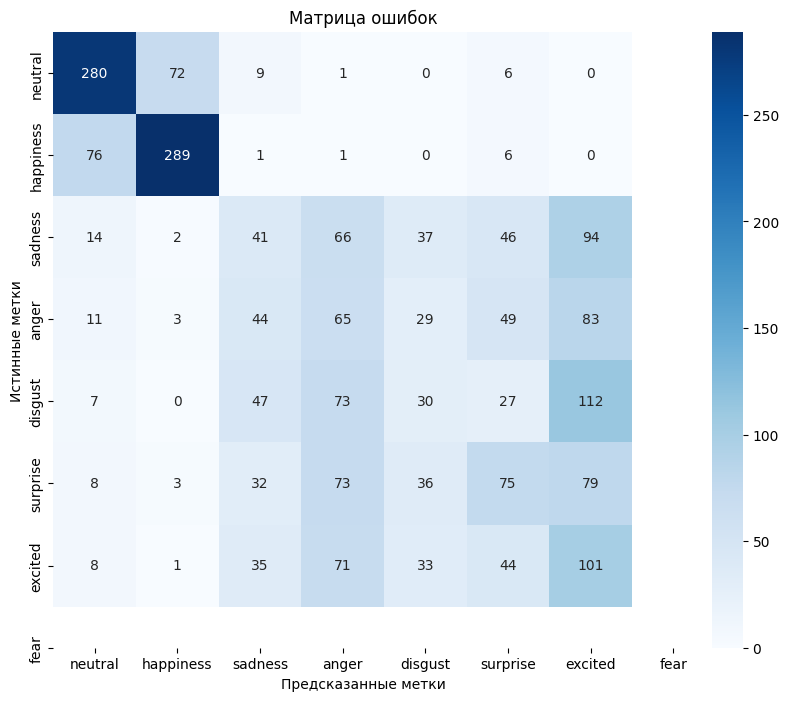

In [ ]:
# Матрица ошибок
cm = confusion_matrix(y_val, predicted_classes)
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=emotion_mapping.keys(),
            yticklabels=emotion_mapping.keys())
plt.xlabel('Предсказанные метки')
plt.ylabel('Истинные метки')
plt.title('Матрица ошибок')
plt.show()

In [ ]:
report = classification_report(y_val, predicted_classes, target_names=list(emotion_mapping.keys())[:7])
print(report)

              precision    recall  f1-score   support

     neutral       0.69      0.76      0.73       368
   happiness       0.78      0.77      0.78       373
     sadness       0.20      0.14      0.16       300
       anger       0.19      0.23      0.21       284
     disgust       0.18      0.10      0.13       296
    surprise       0.30      0.25      0.27       306
     excited       0.22      0.34      0.27       293

    accuracy                           0.40      2220
   macro avg       0.36      0.37      0.36      2220
weighted avg       0.39      0.40      0.39      2220



## ROBERTA

In [ ]:
# Токенизация
tokenizer = AutoTokenizer.from_pretrained("roberta-base")
train_encodings = tokenizer(X_train, truncation=True, padding=True, max_length=128)
val_encodings = tokenizer(X_val, truncation=True, padding=True, max_length=128)

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

In [ ]:
train_dataset = EmotionDataset(train_encodings, y_train)
val_dataset = EmotionDataset(val_encodings, y_val)

In [ ]:
# Загрузка модели
model = AutoModelForSequenceClassification.from_pretrained("roberta-base", num_labels=len(emotion_mapping))
model.to(device)

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


RobertaForSequenceClassification(
  (roberta): RobertaModel(
    (embeddings): RobertaEmbeddings(
      (word_embeddings): Embedding(50265, 768, padding_idx=1)
      (position_embeddings): Embedding(514, 768, padding_idx=1)
      (token_type_embeddings): Embedding(1, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): RobertaEncoder(
      (layer): ModuleList(
        (0-11): 12 x RobertaLayer(
          (attention): RobertaAttention(
            (self): RobertaSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): RobertaSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
         

In [ ]:
# Настройки тренировки
training_args = TrainingArguments(
    output_dir="./results",
    evaluation_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.01,
    logging_dir="./logs",
    logging_steps=10,
    save_strategy="epoch"
)

/usr/local/lib/python3.10/dist-packages/transformers/training_args.py:1575: FutureWarning:

`evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead



In [ ]:
# Тренировка модели
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=lambda p: {
        "accuracy": accuracy_score(p.label_ids, torch.argmax(torch.tensor(p.predictions), dim=1).cpu().numpy()),
        "f1": f1_score(p.label_ids, torch.argmax(torch.tensor(p.predictions), dim=1).cpu().numpy(), average="weighted")
    }
)
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,F1
1,1.387700,1.321904,0.392342,0.341409
2,1.316500,1.299695,0.411261,0.378068
3,1.194700,1.304348,0.408108,0.391369


TrainOutput(global_step=3747, training_loss=1.2916554943987741, metrics={'train_runtime': 1399.4933, 'train_samples_per_second': 42.828, 'train_steps_per_second': 2.677, 'total_flos': 3942734221154304.0, 'train_loss': 1.2916554943987741, 'epoch': 3.0})

In [ ]:
output_dir = "./roberta-base_emotion_model_stratified"

# Сохранение модели
model.save_pretrained(output_dir)

# Сохранение токенизатора
tokenizer.save_pretrained(output_dir)

print(f"Model and tokenizer saved to {output_dir}")

Model and tokenizer saved to ./roberta-base_emotion_model_stratified


In [ ]:
from torch.utils.data import DataLoader, TensorDataset

# Создание DataLoader
test_dataset = TensorDataset(test_encodings["input_ids"], test_encodings["attention_mask"])
test_loader = DataLoader(test_dataset, batch_size=16)

# Инференс с минимальным использованием памяти
predicted_classes = []
model.eval()

with torch.no_grad():
    for batch in test_loader:
        input_ids, attention_mask = [b.to(device) for b in batch]
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        predicted_classes.extend(torch.argmax(outputs.logits, dim=1).cpu().numpy())

print(predicted_classes[:10])

[3, 5, 3, 0, 3, 3, 3, 5, 3, 5]


In [ ]:
# Метрики
accuracy = accuracy_score(y_val, predicted_classes)
f1 = f1_score(y_val, predicted_classes, average='weighted')
precision = precision_score(y_val, predicted_classes, average='weighted')
recall = recall_score(y_val, predicted_classes, average='weighted')

print(f"Accuracy: {accuracy:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")

Accuracy: 0.1887
F1 Score: 0.1646
Precision: 0.2191
Recall: 0.1887


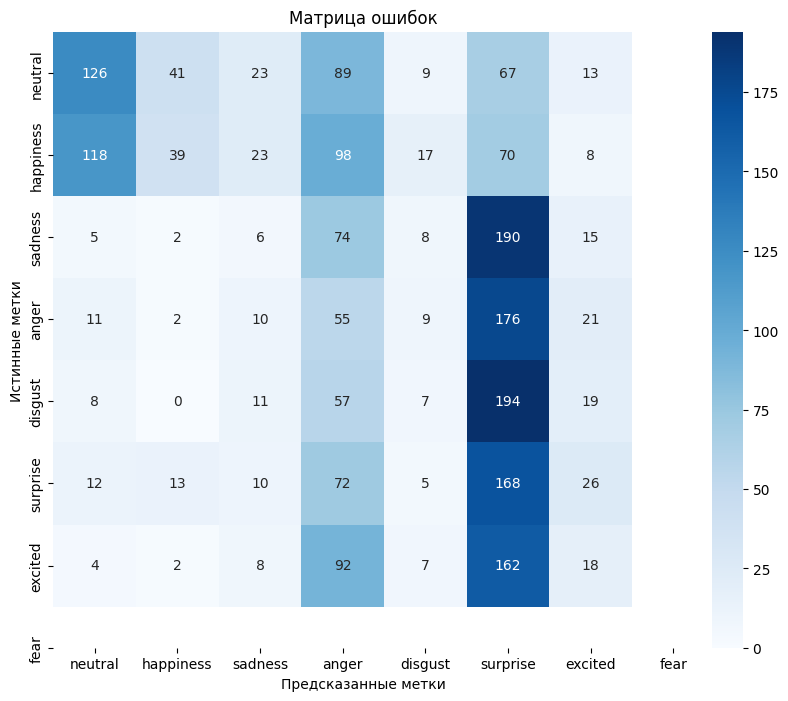

In [ ]:
# Матрица ошибок
cm = confusion_matrix(y_val, predicted_classes)
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=list(emotion_mapping.keys()),
            yticklabels=list(emotion_mapping.keys()))
plt.xlabel('Предсказанные метки')
plt.ylabel('Истинные метки')
plt.title('Матрица ошибок')
plt.show()

In [ ]:
# Отчёт классификации
report = classification_report(y_val, predicted_classes, target_names=list(emotion_mapping.keys())[:7])
print(report)

              precision    recall  f1-score   support

     neutral       0.44      0.34      0.39       368
   happiness       0.39      0.10      0.17       373
     sadness       0.07      0.02      0.03       300
       anger       0.10      0.19      0.13       284
     disgust       0.11      0.02      0.04       296
    surprise       0.16      0.55      0.25       306
     excited       0.15      0.06      0.09       293

    accuracy                           0.19      2220
   macro avg       0.20      0.18      0.16      2220
weighted avg       0.22      0.19      0.16      2220



## DistilBERTA

In [ ]:
test_df = [text for text in test_df if isinstance(text, str) and text.strip()]

In [ ]:
# Токенизация
tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")
train_encodings = tokenizer(X_train, truncation=True, padding=True, max_length=128)
val_encodings = tokenizer(X_val, truncation=True, padding=True, max_length=128)
test_encodings = tokenizer(test_df, truncation=True, padding=True, max_length=128)

In [ ]:
train_dataset = EmotionDataset(train_encodings, y_train)
val_dataset = EmotionDataset(val_encodings, y_val)

In [ ]:
# Загрузка модели
model = AutoModelForSequenceClassification.from_pretrained("distilbert-base-uncased", num_labels=len(emotion_mapping))
model.to(device)

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


DistilBertForSequenceClassification(
  (distilbert): DistilBertModel(
    (embeddings): Embeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (transformer): Transformer(
      (layer): ModuleList(
        (0-5): 6 x TransformerBlock(
          (attention): DistilBertSdpaAttention(
            (dropout): Dropout(p=0.1, inplace=False)
            (q_lin): Linear(in_features=768, out_features=768, bias=True)
            (k_lin): Linear(in_features=768, out_features=768, bias=True)
            (v_lin): Linear(in_features=768, out_features=768, bias=True)
            (out_lin): Linear(in_features=768, out_features=768, bias=True)
          )
          (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
          (ffn): FFN(
            (dropout): Dropout(p=0.1, inplace=False)


In [ ]:
# Настройки тренировки
training_args = TrainingArguments(
    output_dir="./results",
    evaluation_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.01,
    logging_dir="./logs",
    logging_steps=10,
    save_strategy="epoch"
)

/usr/local/lib/python3.10/dist-packages/transformers/training_args.py:1575: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(


In [ ]:
# Тренировка модели
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=lambda p: {
        "accuracy": accuracy_score(p.label_ids, torch.argmax(torch.tensor(p.predictions), dim=1).cpu().numpy()),
        "f1": f1_score(p.label_ids, torch.argmax(torch.tensor(p.predictions), dim=1).cpu().numpy(), average="weighted")
    }
)
trainer.train()

wandb: WARNING The `run_name` is currently set to the same value as `TrainingArguments.output_dir`. If this was not intended, please specify a different run name by setting the `TrainingArguments.run_name` parameter.
wandb: Using wandb-core as the SDK backend.  Please refer to https://wandb.me/wandb-core for more information.


<IPython.core.display.Javascript object>

wandb: Logging into wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: You can find your API key in your browser here: https://wandb.ai/authorize
wandb: Paste an API key from your profile and hit enter, or press ctrl+c to quit:

 ··········


wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,1.405900,1.324229,0.389189,0.360109
2,1.288300,1.306387,0.411261,0.377661
3,1.212100,1.311236,0.402703,0.391295


TrainOutput(global_step=3747, training_loss=1.2940663700902943, metrics={'train_runtime': 749.2427, 'train_samples_per_second': 79.997, 'train_steps_per_second': 5.001, 'total_flos': 1985137008187392.0, 'train_loss': 1.2940663700902943, 'epoch': 3.0})

In [ ]:
output_dir = "./distilbert-base-uncased_emotion_model_stratified"

# Сохранение модели
model.save_pretrained(output_dir)

# Сохранение токенизатора
tokenizer.save_pretrained(output_dir)


print(f"Model and tokenizer saved to {output_dir}")

Model and tokenizer saved to ./distilbert-base-uncased_emotion_model_stratified


In [ ]:
test_encodings = tokenizer(
    X_val,
    truncation=True,
    padding=True,
    max_length=128,
    return_tensors="pt"
)

# Удаляем 'token_type_ids', так как DistilBERT его не использует
if 'token_type_ids' in test_encodings:
    test_encodings.pop('token_type_ids')
# Перенос токенизированных данных на устройство (CPU или GPU)
test_encodings = {key: val.to(model.device) for key, val in test_encodings.items()}

# Передача данных в модель для получения предсказаний
model.eval()
with torch.no_grad():
    predictions = model(**test_encodings)

# Получение предсказанных классов
predicted_classes = torch.argmax(predictions.logits, dim=1)
print(predicted_classes)

tensor([2, 1, 1,  ..., 1, 3, 1], device='cuda:0')


In [ ]:
from torch.utils.data import DataLoader, TensorDataset

# Создание DataLoader
test_dataset = TensorDataset(test_encodings["input_ids"], test_encodings["attention_mask"])
test_loader = DataLoader(test_dataset, batch_size=16)

# Инференс с минимальным использованием памяти
predicted_classes = []
model.eval()

with torch.no_grad():
    for batch in test_loader:
        input_ids, attention_mask = [b.to(device) for b in batch]
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        predicted_classes.extend(torch.argmax(outputs.logits, dim=1).cpu().numpy())

print(predicted_classes[:10])

[2, 1, 1, 0, 6, 6, 1, 0, 3, 6]


In [ ]:
# Метрики
accuracy = accuracy_score(y_val, predicted_classes)
f1 = f1_score(y_val, predicted_classes, average='weighted')
precision = precision_score(y_val, predicted_classes, average='weighted')
recall = recall_score(y_val, predicted_classes, average='weighted')

print(f"Accuracy: {accuracy:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")

Accuracy: 0.4027
F1 Score: 0.3913
Precision: 0.4000
Recall: 0.4027


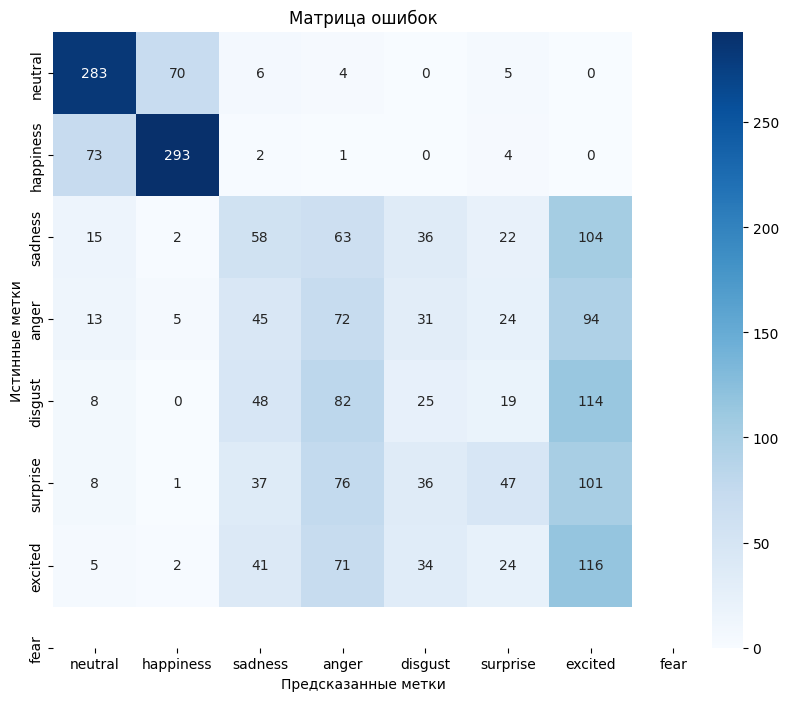

In [ ]:
# Матрица ошибок
cm = confusion_matrix(y_val, predicted_classes)
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=list(emotion_mapping.keys()),
            yticklabels=list(emotion_mapping.keys()))
plt.xlabel('Предсказанные метки')
plt.ylabel('Истинные метки')
plt.title('Матрица ошибок')
plt.show()

In [ ]:
# Отчёт классификации
report = classification_report(y_val, predicted_classes, target_names=list(emotion_mapping.keys())[:7])
print(report)

              precision    recall  f1-score   support

     neutral       0.70      0.77      0.73       368
   happiness       0.79      0.79      0.79       373
     sadness       0.24      0.19      0.22       300
       anger       0.20      0.25      0.22       284
     disgust       0.15      0.08      0.11       296
    surprise       0.32      0.15      0.21       306
     excited       0.22      0.40      0.28       293

    accuracy                           0.40      2220
   macro avg       0.37      0.38      0.36      2220
weighted avg       0.40      0.40      0.39      2220



## Сравнение Transformers

In [ ]:
data = {
    'Model': ['bert-base-uncased', 'roberta-base', 'distilbert-base-uncased'],
    'Accuracy': [0.3968, 0.1887, 0.4027],
    'F1 Score': [0.3883, 0.1646, 0.3913],
    'Precision': [ 0.3899, 0.2191, 0.4000],
    'Recall': [0.3968, 0.1887, 0.4027]
}

df = pd.DataFrame(data)
df_sorted = df.sort_values(by='Accuracy', ascending=False)
df_sorted_reset = df_sorted.reset_index(drop=True)
pd.set_option('display.float_format', '{:.4f}'.format)
styled_df = df_sorted_reset.style.set_caption("Сравнение моделей") \
    .background_gradient(cmap='viridis', subset=['Accuracy', 'F1 Score', 'Precision', 'Recall']) \
    .format({
        'Accuracy': "{:.4f}",
        'F1 Score': "{:.4f}",
        'Precision': "{:.4f}",
        'Recall': "{:.4f}"
    }) \
    .set_table_styles(
        [{
            'selector': 'th',
            'props': [('background-color', '#f7f7f9'),
                      ('color', 'black'),
                      ('border', '1px solid black')]
        },
        {
            'selector': 'td',
            'props': [('border', '1px solid black')]
        }]
    )

styled_df

,Model,Accuracy,F1 Score,Precision,Recall
0,distilbert-base-uncased,0.4027,0.3913,0.4000,0.4027
1,bert-base-uncased,0.3968,0.3883,0.3899,0.3968
2,roberta-base,0.1887,0.1646,0.2191,0.1887


# Сравнение всех моделей

In [ ]:
import pandas as pd

data1 = {
    'Model': ['SVM', 'Naive Bayes'],
    'Accuracy': [0.3563, 0.3396],
    'F1 Score': [0.3466, 0.3178]
}

data2 = {
    'Model': ['RNN', 'LSTM'],
    'Accuracy': [0.0611, 0.5422],
    'F1 Score': [0.0072, 0.3818]
}

data3 = {
    'Model': ['bert-base-uncased', 'roberta-base', 'distilbert-base-uncased'],
    'Accuracy': [0.3968, 0.1887, 0.4027],
    'F1 Score': [0.3883, 0.1646, 0.3913],
    'Precision': [ 0.3899, 0.2191, 0.4000],
    'Recall': [0.3968, 0.1887, 0.4027]
}

df1 = pd.DataFrame(data1)
df2 = pd.DataFrame(data2)
df3 = pd.DataFrame(data3)

df1['Model Type'] = 'Classic'
df2['Model Type'] = 'Neural Network'
df3['Model Type'] = 'Transformers'

df_all = pd.concat([df1, df2, df3], ignore_index=True)

df_all = df_all.drop(columns=['Precision', 'Recall'], errors='ignore')

df_sorted = df_all.sort_values(by='Accuracy', ascending=False).reset_index(drop=True)

# Форматирование
pd.set_option('display.float_format', '{:.4f}'.format)

# Стилизация
styled_df = df_sorted.style.set_caption("Сравнение моделей") \
    .background_gradient(cmap='viridis', subset=['Accuracy', 'F1 Score']) \
    .format({
        'Accuracy': "{:.4f}",
        'F1 Score': "{:.4f}"
    }) \
    .set_table_styles(
        [{
            'selector': 'th',
            'props': [('background-color', '#f7f7f9'),
                      ('color', 'black'),
                      ('border', '1px solid black')]
        },
        {
            'selector': 'td',
            'props': [('border', '1px solid black')]
        }]
    )

styled_df


,Model,Accuracy,F1 Score,Model Type
0,LSTM,0.5422,0.3818,Neural Network
1,distilbert-base-uncased,0.4027,0.3913,Transformers
2,bert-base-uncased,0.3968,0.3883,Transformers
3,SVM,0.3563,0.3466,Classic
4,Naive Bayes,0.3396,0.3178,Classic
5,roberta-base,0.1887,0.1646,Transformers
6,RNN,0.0611,0.0072,Neural Network
